# 06 — Supervised: Price Imputation + Affluence Drivers

Impute missing residential prices (LightGBM, cross-validated, benchmarked vs city-mean) and explain
affluence drivers with SHAP.

**Improvement-guide changes implemented (with leakage fixes):**
- New predictors added: employer quality/tier, premium hospital/school counts, connectivity (railway/metro/
  highway), office price, neighbour average price, choice intensity, Gini, lifecycle.
- **Text embedding PCA** (20 comps) added as predictors (Improvement 8b).
- **In-fold city target encoding** replaces the raw categorical city (Improvement 8c) — computed *inside*
  each CV fold so there is no leakage.
- **Per-city MAE** reported (Improvement 13.2).
- **SHAP importances exported** to `shap_drivers.csv` for NB07 (Improvement 13.3).

**Leakage guard (my fix, deviates from the guide):** rental yield, price-gap-vs-neighbours, price-vs-belt,
belt avg/max price, and office/residential ratio all embed the target (own buy price) and are **excluded**
from predictors. `neighbour_avg_price` (neighbours only, excludes self) and `off_avg_buy` (a different price
segment) are clean and kept.

Reads `artifacts/localities_segmented.parquet` + `embeddings.npz`; writes `features_imputed.parquet`,
`shap_drivers.png`, `shap_drivers.csv`.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

ART = Path.cwd() / "artifacts"
df = pd.read_parquet(ART / "localities_segmented.parquet").reset_index(drop=True)
print("Rows:", len(df), "| price present:", int(df["res_avg_buy"].notna().sum()),
      "| missing:", int(df["res_avg_buy"].isna().sum()))

Rows: 1001 | price present: 549 | missing: 452


In [2]:
# --- Build predictor matrix (leakage-safe). LightGBM handles NaN natively, so no feature imputation ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

NUM_FEATS = [
    "num_educational_institute", "num_hospital", "num_shopping_centre", "num_transportation_hub",
    "num_commercial_hub", "num_tourist_spot", "num_nearby_localities",
    "total_amenities", "amenity_diversity", "infra_completeness", "retail_civic_balance",
    "choice_intensity", "amenity_gini",
    "num_employers", "primary_sector_score", "employer_quality", "employer_tier_max",
    "sector_information_technology", "sector_finance_and_banking", "sector_consulting",
    "sector_manufacturing_and_industry", "sector_government_and_public_sector",
    "sector_retail_and_commercial", "sector_healthcare_and_pharma",
    "num_premium_hospitals", "num_premium_schools",
    "airport_min", "railway_km", "num_metro_stations_mentioned",
    "off_avg_buy", "neighbor_avg_price",
    "dist_to_city_centroid_km", "knn_density_km",
    "graph_degree", "graph_pagerank", "graph_clustering", "belt_size",
]
NUM_FEATS = [c for c in NUM_FEATS if c in df.columns]
X = df[NUM_FEATS].apply(pd.to_numeric, errors="coerce").copy()
for b in ["is_metro_connected", "is_highway_adjacent"]:
    if b in df.columns:
        X[b] = df[b].astype(float)
for c in ["maturity", "lifecycle"]:
    if c in df.columns:
        X[c] = df[c].astype("category")

# Improvement 8b: text-embedding PCA components
emb = np.load(ART / "embeddings.npz", allow_pickle=True)["combined"]
emb_pca = PCA(n_components=20, random_state=42).fit_transform(StandardScaler().fit_transform(emb))
for i in range(emb_pca.shape[1]):
    X[f"emb_pc{i}"] = emb_pca[:, i]

# Leakage guard
LEAKY = {"res_avg_buy", "res_min_buy", "res_max_buy", "res_avg_rent", "res_min_rent", "res_max_rent",
         "buy_rent_ratio", "price_spread", "price_spread_pct", "affluence_tier", "rental_yield_pct",
         "price_gap_vs_neighbors", "price_gap_pct", "price_vs_belt", "belt_avg_price", "belt_max_price",
         "office_residential_ratio", "res_avg_buy_z", "affluence_x_amenities"}
assert not (set(X.columns) & LEAKY), f"LEAK: {set(X.columns) & LEAKY}"

y = df["res_avg_buy"]
present = y.notna().values
print("Predictors:", X.shape[1], "| training rows:", int(present.sum()))

Predictors: 61 | training rows: 549


In [3]:
# --- Cross-validated LightGBM (with in-fold city target encoding) vs city-mean baseline ---
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error

Xp = X[present].reset_index(drop=True)
yp = y[present].values
cities = df.loc[present, "ADDRESS"].reset_index(drop=True).values

def make_model():
    return LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=31,
                         subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof = np.empty(len(yp)); base = np.empty(len(yp))
for tr, te in kf.split(Xp):
    city_means = pd.Series(yp[tr]).groupby(cities[tr]).mean()
    gm = yp[tr].mean()
    Xtr, Xte = Xp.iloc[tr].copy(), Xp.iloc[te].copy()
    Xtr["city_target_enc"] = [city_means.get(c, gm) for c in cities[tr]]
    Xte["city_target_enc"] = [city_means.get(c, gm) for c in cities[te]]
    m = make_model().fit(Xtr, yp[tr])
    oof[te] = m.predict(Xte)
    base[te] = [city_means.get(c, gm) for c in cities[te]]

r2, mae = r2_score(yp, oof), mean_absolute_error(yp, oof)
r2b, maeb = r2_score(yp, base), mean_absolute_error(yp, base)
print(f"LightGBM (features + target-enc) : R2 = {r2:.3f} | MAE = Rs {mae:,.0f}/sqft")
print(f"City-mean baseline              : R2 = {r2b:.3f} | MAE = Rs {maeb:,.0f}/sqft")
print("--> features add signal beyond geography:", "YES" if r2 > r2b else "NO (use baseline)")

# Improvement 13.2: per-city MAE
cm = pd.DataFrame({"city": cities, "actual": yp, "pred": oof})
print("\nPer-city MAE (Rs/sqft):")
print(cm.groupby("city").apply(lambda g: mean_absolute_error(g["actual"], g["pred"])).round(0).sort_values().to_string())

LightGBM (features + target-enc) : R2 = 0.736 | MAE = Rs 3,610/sqft
City-mean baseline              : R2 = 0.492 | MAE = Rs 5,035/sqft
--> features add signal beyond geography: YES

Per-city MAE (Rs/sqft):
city
Lucknow       1580.0
Pune          2191.0
Hyderabad     2241.0
Kolkata       2329.0
Bangalore     3221.0
Chennai       3271.0
Gurugram      3587.0
New Delhi     5232.0
Chandigarh    6199.0
Mumbai        6304.0


Top 12 affluence drivers (mean |SHAP|):
neighbor_avg_price              4463.3
city_target_enc                 2241.2
primary_sector_score             400.7
emb_pc5                          333.9
dist_to_city_centroid_km         316.8
amenity_diversity                312.2
sector_retail_and_commercial     311.7
emb_pc16                         271.9
emb_pc6                          266.3
emb_pc17                         264.2
belt_size                        231.8
off_avg_buy                      224.2


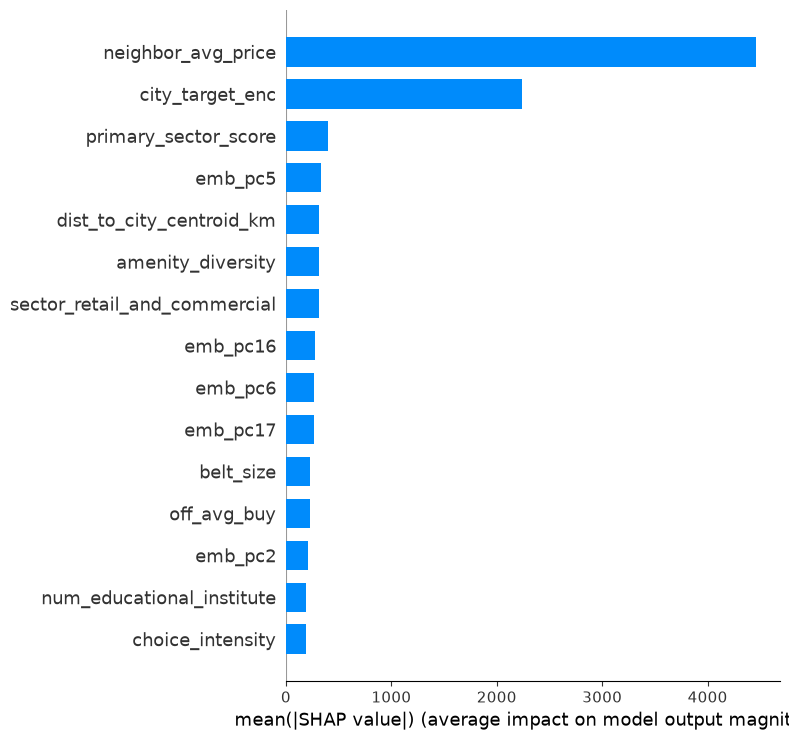


Saved shap_drivers.png + shap_drivers.csv


In [4]:
# --- Final model on all present + SHAP drivers (export for NB07) ---
import shap
import matplotlib.pyplot as plt

city_means_all = pd.Series(yp).groupby(cities).mean()
gm_all = yp.mean()
Xp_full = Xp.copy()
Xp_full["city_target_enc"] = [city_means_all.get(c, gm_all) for c in cities]
model = make_model().fit(Xp_full, yp)

sv = shap.TreeExplainer(model).shap_values(Xp_full)
imp = pd.Series(np.abs(sv).mean(axis=0), index=Xp_full.columns).sort_values(ascending=False)
imp.to_csv(ART / "shap_drivers.csv", header=["mean_abs_shap"])
print("Top 12 affluence drivers (mean |SHAP|):")
print(imp.head(12).round(1).to_string())

plt.figure()
shap.summary_plot(sv, Xp_full, plot_type="bar", max_display=15, show=False)
plt.tight_layout()
plt.savefig(ART / "shap_drivers.png", dpi=110, bbox_inches="tight")
plt.show()
print("\nSaved shap_drivers.png + shap_drivers.csv")

In [5]:
# --- Impute missing prices (real kept; predictions flagged) ---
miss = ~present
Xmiss = X[miss].copy()
Xmiss["city_target_enc"] = [city_means_all.get(c, gm_all) for c in df.loc[miss, "ADDRESS"]]
df["res_avg_buy_imputed"] = df["res_avg_buy"]
df.loc[miss, "res_avg_buy_imputed"] = model.predict(Xmiss).round(0)
df["price_is_imputed"] = miss

print("Imputed", int(miss.sum()), "missing prices.")
print(f"Real    avg Rs {df.loc[present, 'res_avg_buy'].mean():,.0f}/sqft | "
      f"Imputed avg Rs {df.loc[miss, 'res_avg_buy_imputed'].mean():,.0f}/sqft")

out = ART / "features_imputed.parquet"
df.to_parquet(out, index=False)
print("\nSaved", df.shape[0], "rows x", df.shape[1], "cols ->", out.relative_to(Path.cwd()))

Imputed 452 missing prices.
Real    avg Rs 14,625/sqft | Imputed avg Rs 12,170/sqft

Saved 1001 rows x 118 cols -> artifacts\features_imputed.parquet


## Output
`features_imputed.parquet` + `shap_drivers.png` + `shap_drivers.csv` — model-imputed affluence
(`res_avg_buy_imputed` + `price_is_imputed` flag) and an exported SHAP driver ranking for NB07.

**Honesty note:** trust the imputation only if CV R² beats the city-mean baseline (printed above), and read
the per-city MAE — the model is stronger for data-rich, well-differentiated cities than for thin ones.

**Next:** `07_similarity_anomaly_synthesis.ipynb` — lookalikes, anomaly + spillover gems, learned ICP weights,
Pareto frontier, and the consolidated master store.